<a href="https://colab.research.google.com/github/alealvaradoj131020/TextAnalytics_Proyecto/blob/main/ProyectoTextAnalytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análisis de sentimiento y modelado de tópicos**

**Proyecto Final Text Analytics - Master In Business Intelligence and Analytics**

Carlos Rivera - 251518

Daniel Cabrera - 252136

Alejandra Alvarado - 18263

# Introducción

Este proyecto tiene como objetivo analizar reseñas de Amazon para identificar patrones lingüísticos asociados a opiniones positivas y negativas, así como evaluar modelos de clasificación automática de sentimiento.

## Caso de uso

El análisis busca responder:
- ¿Qué palabras y estructuras caracterizan una reseña positiva o negativa?
- ¿Qué tan bien se puede automatizar esta clasificación?
- ¿Qué temas predominan en las reseñas y cómo se relacionan con el sentimiento?

## **1. Fuente de Datos**

¡Éxito! Dataset cargado.
El dataset tiene 20000 filas y 2 columnas.
                                          reviewText  Positive
0  This is a one of the best apps acording to a b...         1
1  This is a pretty good version of the game for ...         1
2  this is a really cool game. there are a bunch ...         1
3  This is a silly game and can be frustrating, b...         1
4  This is a terrific game on any pad. Hrs of fun...         1


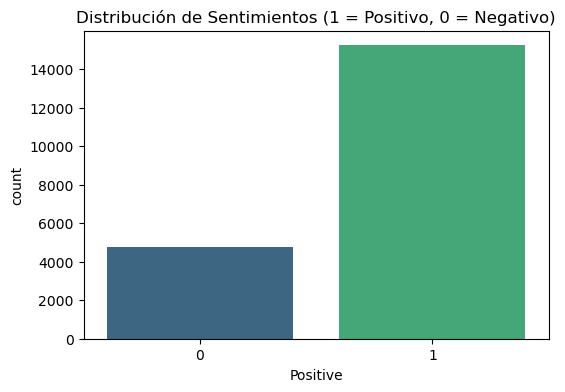

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/pycaret/pycaret/master/datasets/amazon.csv"

# Cargamos los datos
df = pd.read_csv(url)
print("¡Éxito! Dataset cargado.")
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")

# Mostramos las primeras 5 filas
print(df.head())

# Visualizamos si los datos están balanceados
plt.figure(figsize=(6,4))
sns.countplot(x='Positive', data=df, palette='viridis')
plt.title('Distribución de Sentimientos (1 = Positivo, 0 = Negativo)')
plt.show()

## **2. Pre-procesamiento de Datos**

- Limpieza de texto
- Tokenización
- Stopwords
- Lemmatization

In [16]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# Cargamos las herramientas necesarias de NLTK
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('punkt_tab')

# Definimos las palabras "vacías" (las que no queremos en el análisis)
stop_words = set(stopwords.words('english'))

# Inicializamos el Lematizador
lemmatizer = WordNetLemmatizer()

def limpiar_texto_avanzado(texto):
    # 1. Pasamos todo a minúsculas
    texto = str(texto).lower()

    # 2. Quitamos etiquetas HTML
    texto = re.sub(r'<.*?>', '', texto)

    # 3. Quitamos caracteres especiales y números
    texto = re.sub(r'<.*?>', '', texto)
    texto = re.sub(r'[^a-zA-Z\s]', '', texto)

    # 4. Tokenización
    palabras = nltk.word_tokenize(texto)

    # 5. Quitamos Stopwords y palabras muy cortas
    # También aplicamos Lematización a cada palabra
    palabras_limpias = [
        lemmatizer.lemmatize(p) for p in palabras
        if p not in stop_words and len(p) > 2
    ]

    # 6. Volvemos a unir las palabras en una sola cadena de texto
    return " ".join(palabras_limpias)

print("Iniciando limpieza de texto.")

# Creamos una nueva columna con el texto limpio
df['clean_text'] = df['reviewText'].apply(limpiar_texto_avanzado)

print("¡Limpieza completada!")

# Comparación de resultados
print("\n--- COMPARACIÓN DE RESULTADOS ---")
print(f"Original: {df['reviewText'].iloc[0][:100]}...")
print(f"Limpio:   {df['clean_text'].iloc[0][:100]}...")

Iniciando limpieza de texto.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\carlo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\carlo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\carlo\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\carlo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\carlo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


¡Limpieza completada!

--- COMPARACIÓN DE RESULTADOS ---
Original: This is a one of the best apps acording to a bunch of people and I agree it has bombs eggs pigs TNT ...
Limpio:   one best apps acording bunch people agree bomb egg pig tnt king pig realustic stuff...


## **3. Analisis Exploratorio EDA**

c:\Users\carlo\anaconda3\lib\site-packages\seaborn\_core.py:1485: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
c:\Users\carlo\anaconda3\lib\site-packages\seaborn\_core.py:1485: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


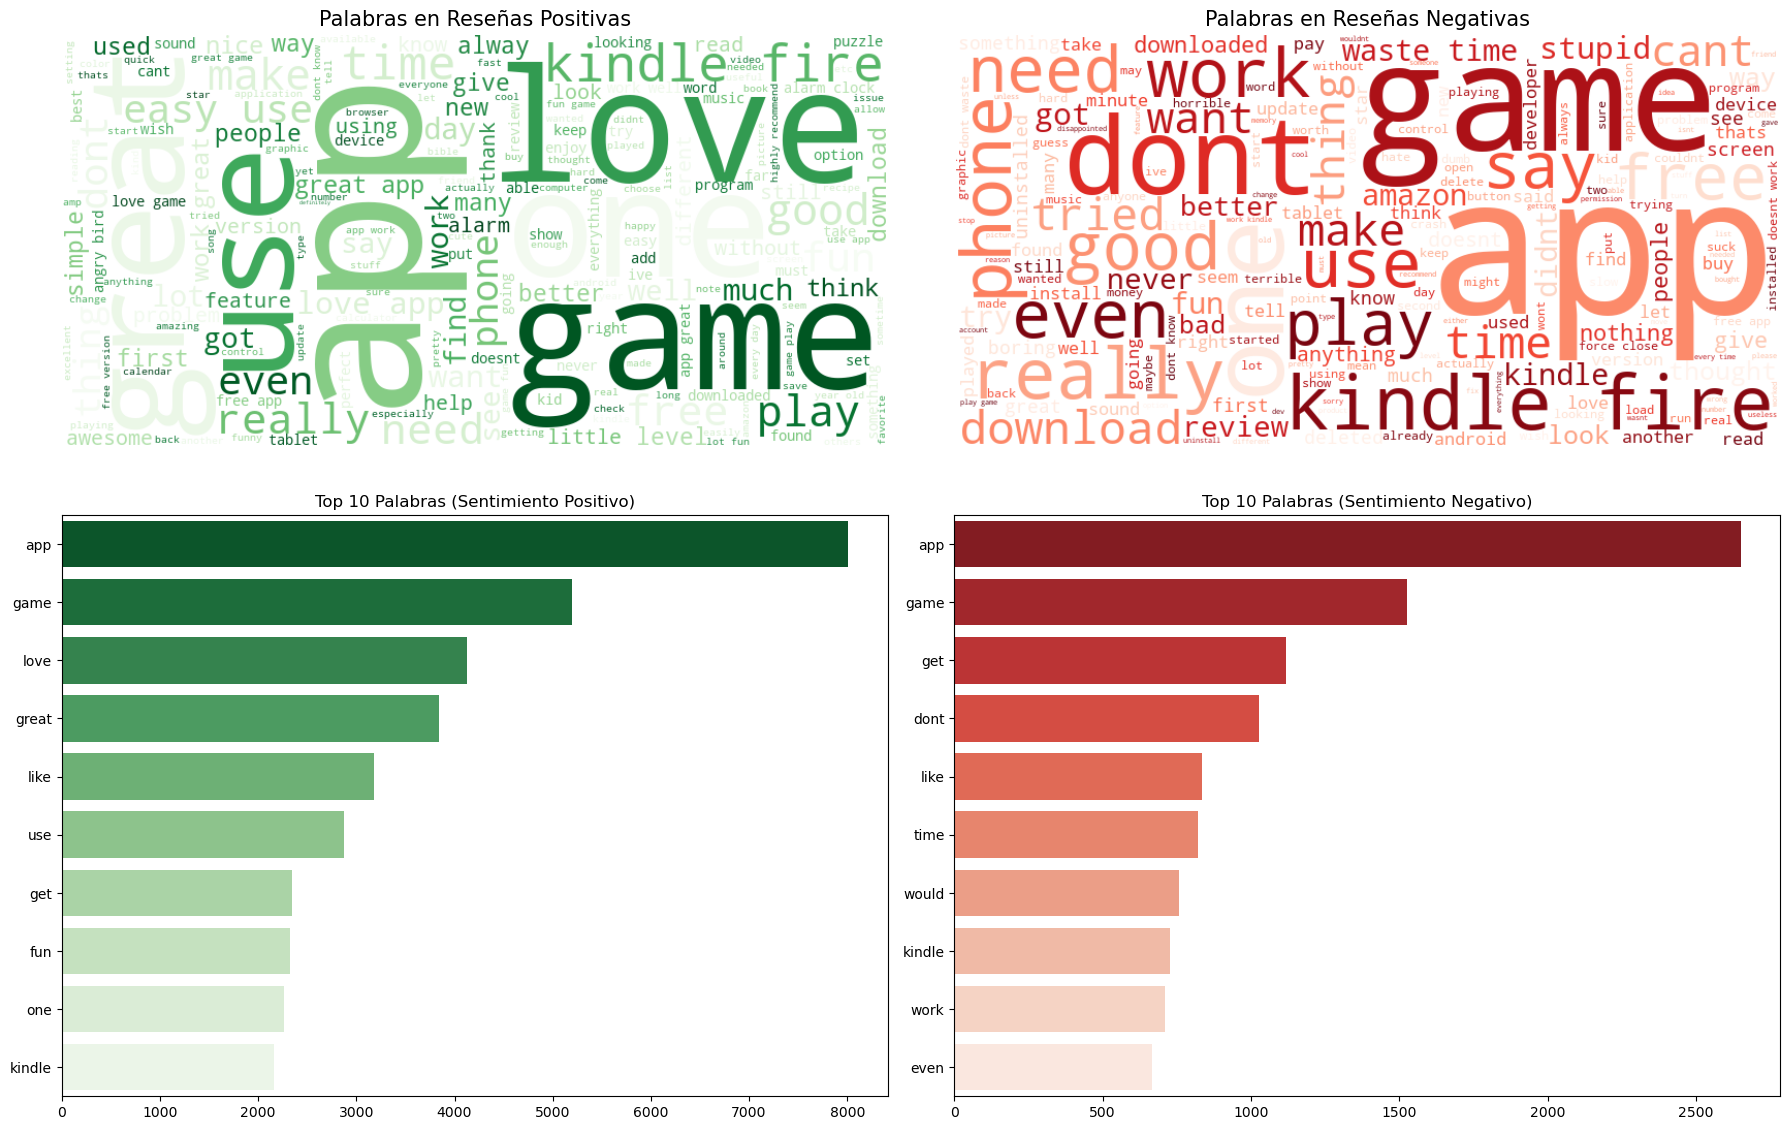


--- ANÁLISIS DE LOS RESULTADOS ---
Palabra más frecuente en positivos: 'app'
Palabra más frecuente en negativos: 'app'


In [17]:
from wordcloud import WordCloud
from collections import Counter

# Separamos los datos por sentimiento para compararlos
positivos = df[df['Positive'] == 1]['clean_text']
negativos = df[df['Positive'] == 0]['clean_text']

# Obtenemos las palabras más comunes
def obtener_frecuencias(dataset):
    todas_las_palabras = " ".join(dataset).split()
    return Counter(todas_las_palabras).most_common(10)

fig, ax = plt.subplots(2, 2, figsize=(18, 12))

# 1. Nube de Palabras - Positivas
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(" ".join(positivos))
ax[0, 0].imshow(wordcloud_pos, interpolation='bilinear')
ax[0, 0].set_title('Palabras en Reseñas Positivas', fontsize=15)
ax[0, 0].axis('off')

# 2. Nube de Palabras - Negativas
wordcloud_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(" ".join(negativos))
ax[0, 1].imshow(wordcloud_neg, interpolation='bilinear')
ax[0, 1].set_title('Palabras en Reseñas Negativas', fontsize=15)
ax[0, 1].axis('off')

# 3. Gráfico de Barras - Top 10 Positivas
top_pos = obtener_frecuencias(positivos)
words_p, counts_p = zip(*top_pos)
sns.barplot(x=list(counts_p), y=list(words_p), ax=ax[1, 0], palette='Greens_r')
ax[1, 0].set_title('Top 10 Palabras (Sentimiento Positivo)')

# 4. Gráfico de Barras - Top 10 Negativas
top_neg = obtener_frecuencias(negativos)
words_n, counts_n = zip(*top_neg)
sns.barplot(x=list(counts_n), y=list(words_n), ax=ax[1, 1], palette='Reds_r')
ax[1, 1].set_title('Top 10 Palabras (Sentimiento Negativo)')

plt.tight_layout()
plt.show()

print("\n--- ANÁLISIS DE LOS RESULTADOS ---")
print(f"Palabra más frecuente en positivos: '{top_pos[0][0]}'")
print(f"Palabra más frecuente en negativos: '{top_neg[0][0]}'")

## Análisis

Las reseñas positivas presentan palabras asociadas a satisfacción y emociones favorables, como "good", "great", "love" o "best". En contraste, las reseñas negativas incluyen términos relacionados con problemas o insatisfacción como "bad", "problem", "waste" o "disappointed".

Esto evidencia que el sentimiento está fuertemente reflejado en el vocabulario utilizado por los usuarios.

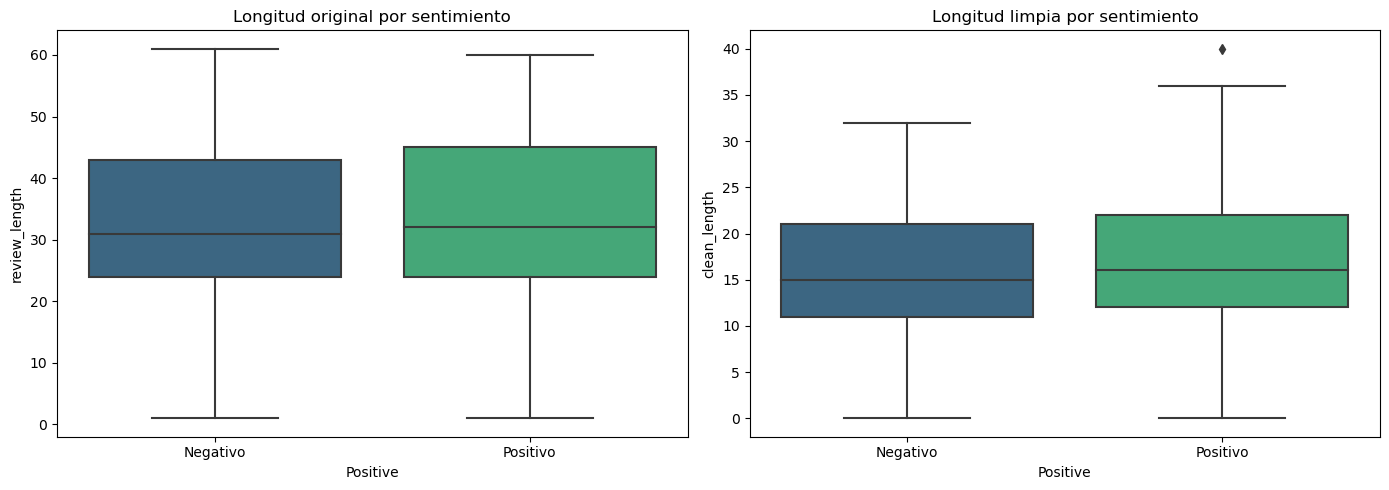

In [18]:
df['review_length'] = df['reviewText'].apply(lambda x: len(str(x).split()))
df['clean_length'] = df['clean_text'].apply(lambda x: len(str(x).split()))

fig, ax = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(data=df, x='Positive', y='review_length', ax=ax[0], palette='viridis')
ax[0].set_title('Longitud original por sentimiento')
ax[0].set_xticklabels(['Negativo', 'Positivo'])

sns.boxplot(data=df, x='Positive', y='clean_length', ax=ax[1], palette='viridis')
ax[1].set_title('Longitud limpia por sentimiento')
ax[1].set_xticklabels(['Negativo', 'Positivo'])

plt.tight_layout()
plt.show()

In [19]:
feature_names = vectorizador.get_feature_names_out()
coeficientes = modelo_lr.coef_[0]

top_positivas_idx = coeficientes.argsort()[-15:]
top_negativas_idx = coeficientes.argsort()[:15]

top_positivas = pd.DataFrame({
    'palabra': feature_names[top_positivas_idx],
    'peso': coeficientes[top_positivas_idx]
}).sort_values('peso', ascending=False)

top_negativas = pd.DataFrame({
    'palabra': feature_names[top_negativas_idx],
    'peso': coeficientes[top_negativas_idx]
}).sort_values('peso', ascending=True)

print("Palabras más asociadas a reseñas positivas:")
display(top_positivas)

print("Palabras más asociadas a reseñas negativas:")
display(top_negativas)

Palabras más asociadas a reseñas positivas:


,palabra,peso
14,love,8.324159
13,great,7.920137
12,easy,5.337758
11,awesome,4.776830
10,best,4.437676
9,fun,4.216270
8,perfect,3.334021
7,nice,3.189575
6,well,2.848341
5,favorite,2.795971


Palabras más asociadas a reseñas negativas:


,palabra,peso
0,waste,-5.002661
1,deleted,-4.962124
2,uninstalled,-4.328003
3,boring,-4.093107
4,stupid,-3.879254
5,useless,-3.625795
6,suck,-3.563354
7,worst,-3.348886
8,fix,-3.234162
9,even,-3.167923


## Análisis

Las palabras más frecuentes en ambas clases muestran una estructura común en el lenguaje de las reseñas, sin embargo, las palabras distintivas permiten diferenciar el sentimiento.

Las reseñas positivas tienden a incluir términos de aprobación, mientras que las negativas incluyen palabras que describen fallas, errores o frustraciones.

# **4. Analisis de Sentimiento VADER**

Se utiliza VADER como un modelo basado en reglas léxicas para establecer una línea base de comparación frente a modelos supervisados.

In [20]:
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

df['vader_score'] = df['reviewText'].apply(lambda x: sia.polarity_scores(str(x))['compound'])
df['vader_pred'] = df['vader_score'].apply(lambda x: 1 if x >= 0 else 0)

from sklearn.metrics import accuracy_score, classification_report

print("Resultados VADER")
print("Accuracy:", accuracy_score(df['Positive'], df['vader_pred']))
print(classification_report(df['Positive'], df['vader_pred'], target_names=['Negativo', 'Positivo']))

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\carlo\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Resultados VADER
Accuracy: 0.82175
              precision    recall  f1-score   support

    Negativo       0.66      0.52      0.58      4767
    Positivo       0.86      0.92      0.89     15233

    accuracy                           0.82     20000
   macro avg       0.76      0.72      0.73     20000
weighted avg       0.81      0.82      0.81     20000



## **4. Aplicación de Algoritmos de ML - Aprendizaje Supervisado**


>>> MÉTRICAS PARA NAIVE BAYES <<<
Precisión General (Accuracy): 0.8563
              precision    recall  f1-score   support

    Negativo       0.90      0.45      0.60      1430
    Positivo       0.85      0.98      0.91      4570

    accuracy                           0.86      6000
   macro avg       0.88      0.72      0.75      6000
weighted avg       0.86      0.86      0.84      6000


>>> MÉTRICAS PARA REGRESIÓN LOGÍSTICA <<<
Precisión General (Accuracy): 0.8852
              precision    recall  f1-score   support

    Negativo       0.84      0.64      0.73      1430
    Positivo       0.89      0.96      0.93      4570

    accuracy                           0.89      6000
   macro avg       0.87      0.80      0.83      6000
weighted avg       0.88      0.89      0.88      6000



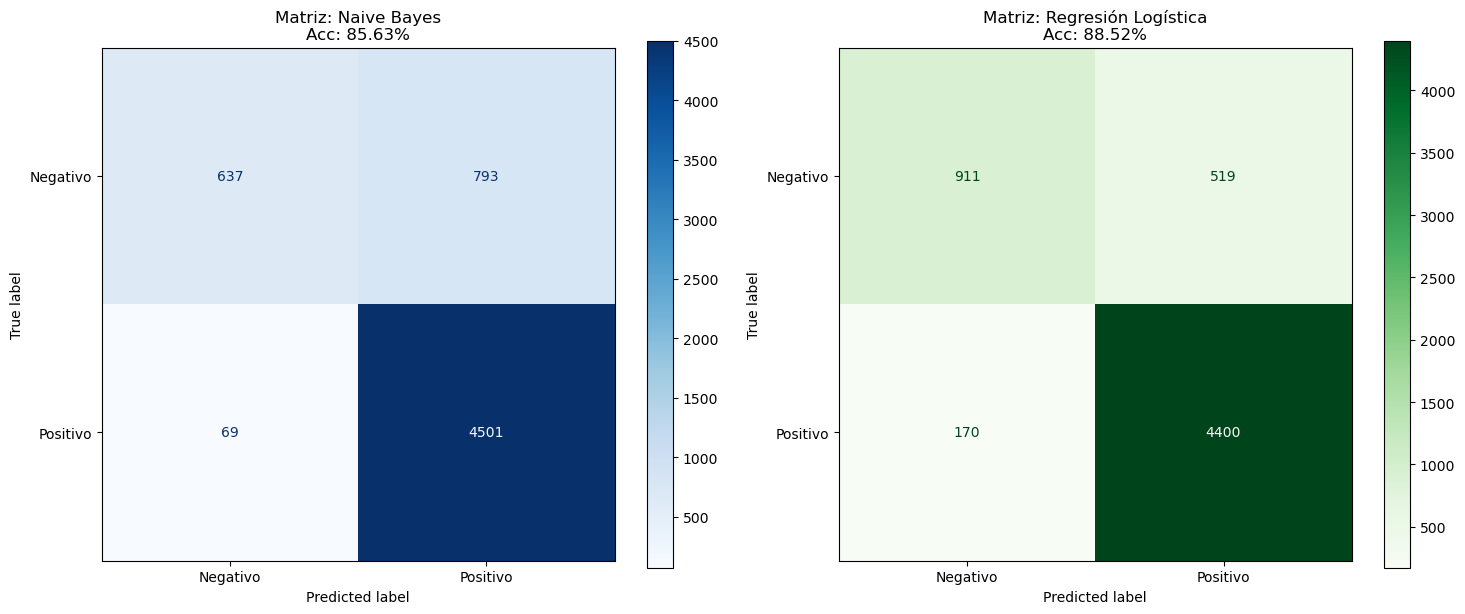

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Convertimos el texto limpio en una matriz de números (TF-IDF)
vectorizador = TfidfVectorizer(max_features=5000)
X = vectorizador.fit_transform(df['clean_text'])
y = df['Positive']

# 70% Entrenamiento / 30% Prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Modelo 1: Naive Bayes
modelo_nb = MultinomialNB()
modelo_nb.fit(X_train, y_train)
pred_nb = modelo_nb.predict(X_test)

# Modelo 2: Regresión Logística
modelo_lr = LogisticRegression(max_iter=1000)
modelo_lr.fit(X_train, y_train)
pred_lr = modelo_lr.predict(X_test)

# EVALUACIÓN DE AMBOS MODELOS

def mostrar_metricas(nombre, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    print(f"\n>>> MÉTRICAS PARA {nombre.upper()} <<<")
    print(f"Precisión General (Accuracy): {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=['Negativo', 'Positivo']))
    return acc

acc_nb = mostrar_metricas("Naive Bayes", y_test, pred_nb)
acc_lr = mostrar_metricas("Regresión Logística", y_test, pred_lr)

# COMPARATIVA VISUAL (Matrices de Confusión)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Matriz para Naive Bayes
ConfusionMatrixDisplay.from_predictions(y_test, pred_nb,
                                        display_labels=['Negativo', 'Positivo'],
                                        cmap='Blues', ax=ax[0])
ax[0].set_title(f'Matriz: Naive Bayes\nAcc: {acc_nb:.2%}')

# Matriz para Regresión Logística
ConfusionMatrixDisplay.from_predictions(y_test, pred_lr,
                                        display_labels=['Negativo', 'Positivo'],
                                        cmap='Greens', ax=ax[1])
ax[1].set_title(f'Matriz: Regresión Logística\nAcc: {acc_lr:.2%}')

plt.tight_layout()
plt.show()

# --- Observaciones ---


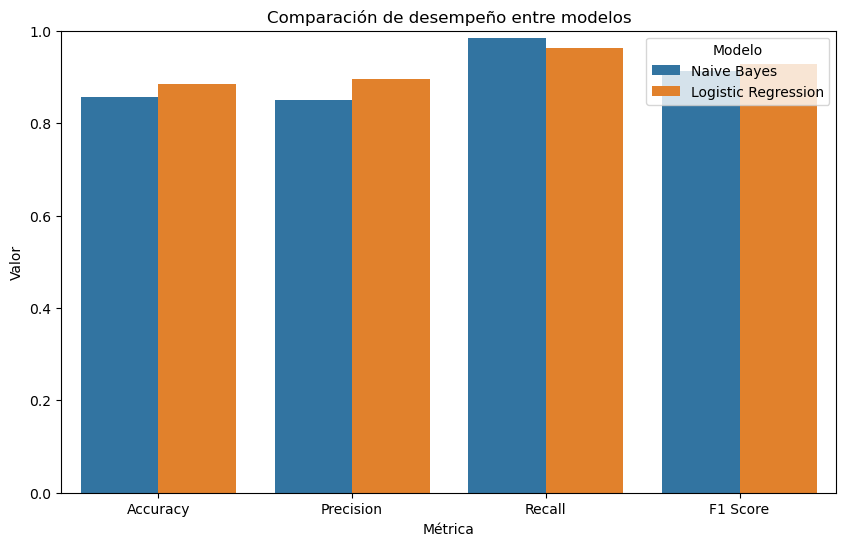

In [22]:
df_plot = resumen_modelos.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

plt.figure(figsize=(10,6))
sns.barplot(data=df_plot, x='Métrica', y='Valor', hue='Modelo')
plt.ylim(0,1)
plt.title('Comparación de desempeño entre modelos')
plt.show()

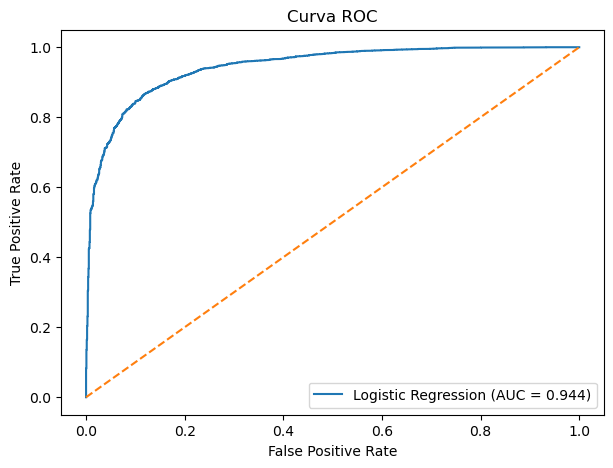

In [23]:
from sklearn.metrics import roc_auc_score, roc_curve

proba_lr = modelo_lr.predict_proba(X_test)[:, 1]
auc_lr = roc_auc_score(y_test, proba_lr)

fpr, tpr, _ = roc_curve(y_test, proba_lr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.show()


## Comparación de enfoques

Se comparan dos enfoques:

- VADER: basado en reglas léxicas
- Modelos supervisados: basados en aprendizaje automático

Esto permite evaluar la diferencia entre métodos simples y modelos entrenados con datos.

In [24]:
resultados = pd.DataFrame({
    'Modelo': ['VADER', 'Logistic Regression', 'Naive Bayes'],
    'Accuracy': [
        accuracy_score(df['Positive'], df['vader_pred']),
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_nb)
    ]
})

resultados

,Modelo,Accuracy
0,VADER,0.821750
1,Logistic Regression,0.885167
2,Naive Bayes,0.856333


Los modelos supervisados superan claramente a VADER, lo que indica que el aprendizaje basado en datos permite capturar patrones más complejos que los métodos léxicos.

## Análisis de resultados

El modelo de Logistic Regression obtuvo el mejor desempeño general con una precisión aproximada del 88%, superando tanto a VADER (82%) como a Naive Bayes (85%).

Además, presenta un mejor balance entre precisión y recall, especialmente en la clase negativa, donde los modelos suelen tener mayor dificultad.

Esto indica que Logistic Regression logra capturar de manera más efectiva los patrones del lenguaje presentes en las reseñas.

## **5. Modelado de Tópicos (LDA) - Aprendizaje No Supervisado**

In [25]:
!pip install gensim
import gensim
from gensim import corpora

# 1. Preparamos los datos para LDA
textos_divididos = [texto.split() for texto in df['clean_text']]

# 2. Creamos un diccionario
diccionario = corpora.Dictionary(textos_divididos)

# Filtramos palabras:
# - Que aparezcan en menos de 5 reseñas (muy raras)
# - Que aparezcan en más del 50% de las reseñas (muy comunes/sin valor)
diccionario.filter_extremes(no_below=5, no_above=0.5)

# 3. Creamos el Corpus: Una "bolsa de palabras" (Bag of Words) para cada reseña
corpus = [diccionario.doc2bow(text) for text in textos_divididos]

# 4. Entrenamos el modelo LDA para encontrar 5 temas ocultos
print("Buscando temas ocultos en las reseñas, esto puede tomar un minuto.")
lda_model = gensim.models.LdaModel(corpus=corpus, id2word=diccionario,
                                   num_topics=5, random_state=42, passes=10)

# 5. Mostramos los temas encontrados con sus 10 palabras más importantes
print("\n--- LOS 5 TEMAS PRINCIPALES DETECTADOS ---")
print("La IA encontró que las reseñas hablan principalmente de estos 5 grupos de palabras:\n")

for idx, topic in lda_model.print_topics(-1):
    # Limpiamos un poco el formato para que sea legible
    palabras_clave = topic.split('"')[1::2]
    print(f"Tema #{idx+1}: {', '.join(palabras_clave)}")


Buscando temas ocultos en las reseñas, esto puede tomar un minuto.

--- LOS 5 TEMAS PRINCIPALES DETECTADOS ---
La IA encontró que las reseñas hablan principalmente de estos 5 grupos de palabras:

Tema #1: app, use, kindle, fire, great, easy, love, work, like, one
Tema #2: app, free, work, version, got, phone, one, amazon, download, tried
Tema #3: app, alarm, love, great, like, use, one, day, set, time
Tema #4: dont, app, get, even, time, like, know, say, people, would
Tema #5: game, fun, love, play, like, great, get, really, time, playing


c:\Users\carlo\anaconda3\lib\site-packages\seaborn\_core.py:1485: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
c:\Users\carlo\anaconda3\lib\site-packages\seaborn\_core.py:1485: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
c:\Users\carlo\anaconda3\lib\site-packages\seaborn\_core.py:1485: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
c:\Users\carlo\anaconda3\lib\site-packages\seaborn\_core.py:1485: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
c:\Users\carlo\anaconda3\lib

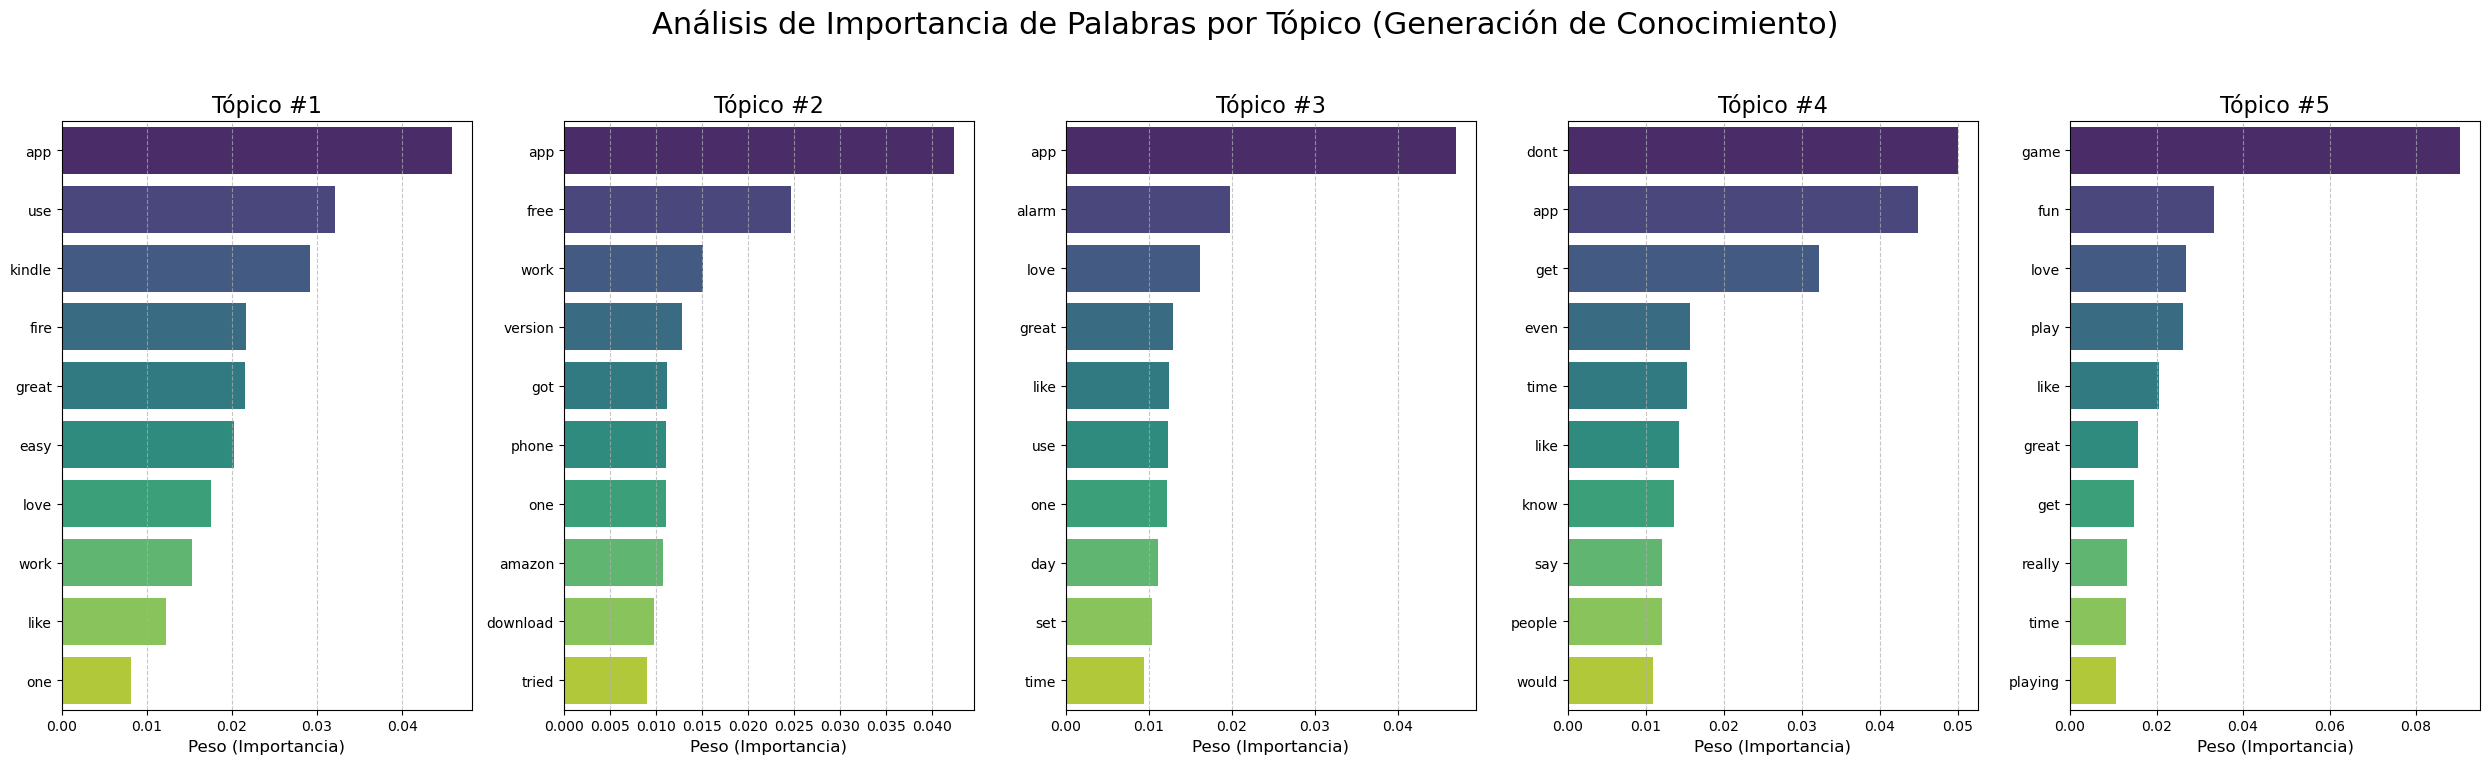

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extraemos los datos de los tópicos del modelo LDA
topics = lda_model.show_topics(formatted=False, num_words=10)

fig, axes = plt.subplots(1, 5, figsize=(25, 8), sharey=False)
fig.suptitle('Análisis de Importancia de Palabras por Tópico (Generación de Conocimiento)', fontsize=22)

# Iteramos sobre cada tópico para crear su gráfica
for i, (topic_num, words) in enumerate(topics):
    # Separamos las palabras y sus pesos (probabilidades)
    palabras = [w[0] for w in words]
    pesos = [w[1] for w in words]

    # Creamos la gráfica de barras horizontal
    sns.barplot(x=pesos, y=palabras, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Tópico #{i+1}', fontsize=16)
    axes[i].set_xlabel('Peso (Importancia)', fontsize=12)
    axes[i].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [27]:
# Obtener tópico dominante por documento
topico_dominante = []

for doc in corpus:
    topicos_doc = lda_model.get_document_topics(doc)
    topico_principal = max(topicos_doc, key=lambda x: x[1])[0]
    topico_dominante.append(topico_principal)

df['topico_dominante'] = topico_dominante

tabla_topicos = pd.crosstab(df['topico_dominante'], df['Positive'], normalize='index')
tabla_topicos.columns = ['Negativo', 'Positivo']

tabla_topicos

,Negativo,Positivo
topico_dominante,,
0,0.098561,0.901439
1,0.443491,0.556509
2,0.141852,0.858148
3,0.622072,0.377928
4,0.134114,0.865886


# Conclusiones

A partir del análisis realizado, se pueden destacar los siguientes hallazgos:

- El lenguaje utilizado en las reseñas permite identificar claramente el sentimiento del usuario, ya que las palabras reflejan directamente experiencias positivas o negativas.

- El modelo de Logistic Regression demostró ser el más efectivo para la clasificación del sentimiento, superando a los enfoques basados en reglas como VADER.

- Las reseñas positivas son más fáciles de identificar debido a la consistencia en el uso de palabras positivas, mientras que las reseñas negativas presentan mayor variabilidad y complejidad.

- El análisis de tópicos permitió identificar temas recurrentes dentro de las reseñas, lo que aporta una visión más profunda sobre los aspectos del producto que influyen en la percepción del usuario.

- Desde una perspectiva de negocio, el análisis de sentimiento permite identificar automáticamente problemas en productos o servicios, facilitando la toma de decisiones basada en datos.